# CARBANAK tree coarsening: stars followed by edge BPE

This experiment reuses the CARBANAK loading, component selection, Graphviz overview, and temporal-dendrogram visualization style from the earlier condensation workbench. It replaces the old burst/evidence coarsener with:

1. `ParametricStarCoarsener`, which contracts repeated sibling labels under common parent labels;
2. `EdgeBPECoarsener`, fitted directly on the transformed Star trees through the shared coarsenable-tree schema.

The notebook shows the intermediate star-coarsened graph before the BPE stage.


## 0. Imports and local package path

This imports the source tree next to the notebook, even if another editable installation exists in the active kernel.


In [1]:
from pathlib import Path
import os
import sys
import math
from collections import Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.collections import LineCollection
from IPython.display import display


def find_project_root(start: Path) -> Path:
    here = start.resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "tree_coarsening").is_dir():
            return candidate
    raise RuntimeError(
        "Could not find a repository root containing pyproject.toml and tree_coarsening/. "
        "Start Jupyter from the repository or edit PROJECT_ROOT directly."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) in sys.path:
    sys.path.remove(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT))
for modname in list(sys.modules):
    if modname == "tree_coarsening" or modname.startswith("tree_coarsening."):
        del sys.modules[modname]

from tree_coarsening import EdgeBPECoarsener, ParametricStarCoarsener
import tree_coarsening as tc

PACKAGE_DIR = PROJECT_ROOT / "tree_coarsening"
imported_from = Path(tc.__file__).resolve()
if PACKAGE_DIR.resolve() not in [imported_from.parent, *imported_from.parents]:
    raise RuntimeError(
        "Imported tree_coarsening from the wrong location.\n"
        f"Expected under: {PACKAGE_DIR.resolve()}\n"
        f"Got: {imported_from}\n"
        "Restart the kernel after updating the package."
    )

print("Kernel Python:", sys.executable)
print("Project root:", PROJECT_ROOT)
print("Imported package from:", imported_from)


Kernel Python: /home/asmi28/anaconda3/envs/steering/bin/python
Project root: /home/asmi28/python_code/tree_condenser_stamp_repo
Imported package from: /home/asmi28/python_code/tree_condenser_stamp_repo/tree_coarsening/__init__.py


## 1. Data paths

The defaults match the earlier CARBANAK notebook. Override `DATA_DIR` directly or set `CARBANAK_DATA_DIR`.


In [2]:
DATA_DIR = Path(os.environ.get("CARBANAK_DATA_DIR", "../../data/CARBANAK")).expanduser().resolve()
PROCESSED_DIR = DATA_DIR / "processed"

EDGE_CSV = PROCESSED_DIR / "carbanak_process_edges_subsample.csv"
LABEL_CSV = PROCESSED_DIR / "carbanak_node_labels_subsample.csv"
TIME_CSV = PROCESSED_DIR / "carbanak_node_times_subsample.csv"

print("DATA_DIR:", DATA_DIR)
print("EDGE_CSV:", EDGE_CSV, EDGE_CSV.exists())
print("LABEL_CSV:", LABEL_CSV, LABEL_CSV.exists())
print("TIME_CSV:", TIME_CSV, TIME_CSV.exists())
if not EDGE_CSV.exists():
    raise FileNotFoundError(f"Run CARBANAK_prep.ipynb first; missing {EDGE_CSV}")


DATA_DIR: /home/asmi28/python_code/data/CARBANAK
EDGE_CSV: /home/asmi28/python_code/data/CARBANAK/processed/carbanak_process_edges_subsample.csv True
LABEL_CSV: /home/asmi28/python_code/data/CARBANAK/processed/carbanak_node_labels_subsample.csv True
TIME_CSV: /home/asmi28/python_code/data/CARBANAK/processed/carbanak_node_times_subsample.csv True


## 2. Load edges, process-name labels, and node times


In [3]:
edges_df = pd.read_csv(EDGE_CSV, dtype={"parent_guid": str, "process_guid": str})
if not {"timestamp", "parent_guid", "process_guid"} <= set(edges_df.columns):
    raise RuntimeError(
        f"Edge CSV has columns {list(edges_df.columns)!r}; expected timestamp,parent_guid,process_guid."
    )

labels_df = None
if LABEL_CSV.exists():
    labels_df = pd.read_csv(LABEL_CSV, dtype={"process_guid": str, "label": str})
    if not {"process_guid", "label"} <= set(labels_df.columns):
        raise RuntimeError(
            f"Label CSV has columns {list(labels_df.columns)!r}; expected process_guid,label."
        )
else:
    print("No label CSV found; labels will be 'unknown'.")


def parse_timestamp_seconds(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().mean() > 0.95:
        med = float(numeric.dropna().median())
        if med > 1e17:
            return numeric / 1e9
        if med > 1e14:
            return numeric / 1e6
        if med > 1e11:
            return numeric / 1e3
        return numeric
    s = series.astype("string").str.strip()
    s = s.str.replace(r"\s+UTC$", "", regex=True)
    s = s.str.replace(r"Z$", "+00:00", regex=True)
    parsed = pd.to_datetime(s, errors="coerce", utc=True)
    if parsed.isna().any():
        raise RuntimeError(
            f"Could not parse timestamps. Examples: {series[parsed.isna()].head(10).tolist()}"
        )
    return parsed.astype("int64") / 1e9


edges_df["_time_seconds"] = parse_timestamp_seconds(edges_df["timestamp"])

if TIME_CSV.exists():
    times_df = pd.read_csv(TIME_CSV, dtype={"process_guid": str})
    node_time = dict(
        zip(
            times_df["process_guid"].astype(str),
            pd.to_numeric(times_df["time"], errors="raise"),
        )
    )
else:
    child_time = edges_df.groupby("process_guid")["_time_seconds"].min()
    parent_time = edges_df.groupby("parent_guid")["_time_seconds"].min()
    all_nodes = set(edges_df["parent_guid"].astype(str)) | set(
        edges_df["process_guid"].astype(str)
    )
    node_time = {}
    for node in all_nodes:
        if node in child_time.index:
            node_time[node] = float(child_time.loc[node])
        elif node in parent_time.index:
            node_time[node] = float(parent_time.loc[node])

node_label = (
    {}
    if labels_df is None
    else dict(zip(labels_df["process_guid"].astype(str), labels_df["label"].astype(str)))
)

print("edge rows:", f"{len(edges_df):,}")
print("known node times:", f"{len(node_time):,}")
print("known node labels:", f"{len(node_label):,}")
display(edges_df.head())
if labels_df is not None:
    display(labels_df.head())


/tmp/ipykernel_1080196/3018305412.py:9: DtypeWarning: Columns (0: top_alert_severities) have mixed types. Specify dtype option on import or set low_memory=False.
  labels_df = pd.read_csv(LABEL_CSV, dtype={"process_guid": str, "label": str})


edge rows: 267,281
known node times: 117,305
known node labels: 117,305


,timestamp,parent_guid,process_guid,_time_seconds
0,2024-04-22 17:32:49 +0000 UTC,7dmf69pk-0c48813d-00000300-00000000-1da92af6fe...,7dmf69pk-0c48813d-00001234-00000000-1da92af715...,1713807.169
1,2024-04-22 17:34:09 +0000 UTC,7dmf69pk-0c48813d-00000a04-00000000-1da94db181...,7dmf69pk-0c48813d-000028ac-00000000-1da94db182...,1713807.249
2,2024-04-22 17:34:09 +0000 UTC,7dmf69pk-0c48813d-00000910-00000374-1da94daa3f...,7dmf69pk-0c48813d-000012b0-00000374-1da94daa4d...,1713807.249
3,2024-04-22 17:34:09 +0000 UTC,7dmf69pk-0c48813d-000016e8-00000000-1da94db288...,7dmf69pk-0c48813d-00002278-00000000-1da94db289...,1713807.249
4,2024-04-22 17:34:09 +0000 UTC,7dmf69pk-0c48813d-00000b00-00000000-1da94db29a...,7dmf69pk-0c48813d-00002b10-00000000-1da94db29a...,1713807.249


,process_guid,label,process_name,n_label_observations,label_source_fields,is_malicious,is_attack_label,alert_label,alert_n_records,alert_n_malicious,alert_n_artifact,alert_n_benign,top_alert_reports,top_alert_severities,n_malicious_votes,n_benign_votes,malicious_source_fields
0,7dmf69pk-0c587426-000003b8-00000000-1da965a2b7...,svchost.exe,svchost.exe,533995,"parent_path,process_path,external_alert:parent...",False,False,unlabelled,0,0,0,0,NaN,NaN,0,0,NaN
1,7dmf69pk-0c587426-00000a64-00000000-1da965a2be...,tiworker.exe,tiworker.exe,518348,"process_path,parent_path,childproc_name",False,False,unlabelled,0,0,0,0,NaN,NaN,0,0,NaN
2,7dmf69pk-0c5454cf-000003a4-00000000-1da959c045...,svchost.exe,svchost.exe,488804,"parent_path,process_path,childproc_name",False,False,unlabelled,0,0,0,0,NaN,NaN,0,0,NaN
3,7dmf69pk-0c5454cf-00000180-00000000-1da959d7fa...,tiworker.exe,tiworker.exe,451586,"process_path,parent_path,childproc_name",False,False,unlabelled,0,0,0,0,NaN,NaN,0,0,NaN
4,7dmf69pk-0c5454cf-000003ac-00000000-1da9a401b4...,svchost.exe,svchost.exe,369318,"parent_path,process_path,external_alert:parent...",False,False,unlabelled,0,0,0,0,NaN,NaN,0,0,NaN


## 3. Build the process graph


In [4]:
G = nx.from_pandas_edgelist(
    edges_df,
    source="parent_guid",
    target="process_guid",
    create_using=nx.DiGraph(),
)
UG = G.to_undirected()

missing_time_nodes = [n for n in UG.nodes() if str(n) not in node_time]
if missing_time_nodes:
    raise RuntimeError(
        f"{len(missing_time_nodes):,} nodes are missing node times. "
        f"Example: {missing_time_nodes[:5]}"
    )

for n in G.nodes():
    uid = str(n)
    G.nodes[n]["uid"] = uid
    G.nodes[n]["time"] = float(node_time[uid])
    G.nodes[n]["label"] = str(node_label.get(uid, "unknown"))
    G.nodes[n]["process_name"] = G.nodes[n]["label"]
    G.nodes[n]["timestamp_label"] = pd.to_datetime(
        float(node_time[uid]), unit="s", utc=True
    ).strftime("%Y-%m-%d %H:%M:%S")

print("directed nodes:", f"{G.number_of_nodes():,}")
print("directed edges:", f"{G.number_of_edges():,}")
print("weak components:", f"{nx.number_weakly_connected_components(G):,}")
print(
    "nodes labelled unknown:",
    f"{sum(1 for n in G if G.nodes[n]['label'] == 'unknown'):,}",
)


directed nodes: 117,305
directed edges: 117,915
weak components: 310
nodes labelled unknown: 3


## 4. Component and visualization helpers

The palette, Graphviz `sfdp` overview, and temporal dendrogram follow the style of the earlier notebook. Graphviz is optional; if `pygraphviz` is missing, the temporal view still runs.


In [5]:
_combined_colors = []
_seen = set()
for cmap_name in ["Set3", "Dark2", "tab20", "tab20b", "tab20c"]:
    cmap = mpl.colormaps[cmap_name]
    colors = cmap.colors if hasattr(cmap, "colors") else [cmap(i) for i in range(cmap.N)]
    for c in colors:
        rgb = tuple(np.round(c[:3], 3))
        if rgb not in _seen:
            _seen.add(rgb)
            _combined_colors.append(c)


def top_label_string(nodes, k=8):
    counts = Counter(G.nodes[n].get("label", "unknown") for n in nodes)
    return ", ".join(f"{label}:{count}" for label, count in counts.most_common(k))


def label_entropy(nodes):
    counts = Counter(G.nodes[n].get("label", "unknown") for n in nodes)
    total = sum(counts.values())
    if total == 0:
        return 0.0
    return -sum((c / total) * math.log(c / total) for c in counts.values() if c)


def component_deltas(H):
    vals = [
        abs(float(G.nodes[u]["time"]) - float(G.nodes[v]["time"]))
        for u, v in H.edges()
    ]
    return pd.Series(vals, name="delta_seconds", dtype="float64")


def component_row(component_id, nodes):
    D = G.subgraph(nodes)
    H = UG.subgraph(nodes)
    deltas = component_deltas(H)
    labels = [G.nodes[n].get("label", "unknown") for n in nodes]
    interesting = [
        "powershell", "cmd", "python", "rundll32", "regsvr32",
        "wscript", "cscript", "msedge", "chrome", "schtasks",
    ]
    hits = sum(any(token in label.lower() for token in interesting) for label in labels)
    if len(deltas):
        frac_le_1 = float((deltas <= 1).mean())
        frac_le_10 = float((deltas <= 10).mean())
        frac_le_60 = float((deltas <= 60).mean())
        q01 = float(deltas.quantile(0.01))
        q10 = float(deltas.quantile(0.10))
        median = float(deltas.median())
    else:
        frac_le_1 = frac_le_10 = frac_le_60 = q01 = q10 = median = 0.0
    times = [G.nodes[n]["time"] for n in nodes]
    return {
        "component_id": int(component_id),
        "n_nodes": len(nodes),
        "n_directed_edges": D.number_of_edges(),
        "n_undirected_edges": H.number_of_edges(),
        "is_tree": nx.is_tree(H) if H.number_of_nodes() else False,
        "max_out_degree": max((D.out_degree(n) for n in D.nodes()), default=0),
        "time_span_seconds": max(times) - min(times),
        "delta_q01": q01,
        "delta_q10": q10,
        "delta_median": median,
        "frac_delta_le_1s": frac_le_1,
        "frac_delta_le_10s": frac_le_10,
        "frac_delta_le_60s": frac_le_60,
        "label_entropy": label_entropy(nodes),
        "interesting_label_hits": hits,
        "burst_score": frac_le_1 + 0.5 * frac_le_10 + 0.25 * frac_le_60,
        "top_labels": top_label_string(nodes),
    }


def is_directed_rooted_tree(D):
    roots = [n for n, degree in D.in_degree() if degree == 0]
    return (
        len(roots) == 1
        and nx.is_directed_acyclic_graph(D)
        and all(D.in_degree(n) == (0 if n == roots[0] else 1) for n in D.nodes())
    )


def make_component_tree(component_id, use_spanning_tree=True):
    nodes = components[int(component_id)]
    U = UG.subgraph(nodes).copy()
    used_spanning_tree = False
    if not nx.is_tree(U):
        if not use_spanning_tree:
            raise RuntimeError(
                f"Component {component_id} is not a tree. Set use_spanning_tree=True."
            )
        U = nx.minimum_spanning_tree(U)
        used_spanning_tree = True

    for n in U.nodes():
        U.nodes[n].update(G.nodes[n])
        U.nodes[n]["uid"] = str(G.nodes[n].get("uid", n))

    # Preserve original process directions when they already define a rooted tree.
    D = nx.DiGraph()
    D.add_nodes_from(U.nodes(data=True))
    for u, v in U.edges():
        if G.has_edge(u, v):
            D.add_edge(u, v)
        elif G.has_edge(v, u):
            D.add_edge(v, u)
        elif U.nodes[u]["time"] <= U.nodes[v]["time"]:
            D.add_edge(u, v)
        else:
            D.add_edge(v, u)

    reoriented = False
    if not is_directed_rooted_tree(D):
        candidate_roots = [
            n for n in U if not any(pred in U for pred in G.predecessors(n))
        ]
        root_pool = candidate_roots or list(U.nodes())
        root = min(root_pool, key=lambda n: (U.nodes[n]["time"], str(n)))
        D = nx.bfs_tree(U, root)
        for n in D.nodes():
            D.nodes[n].update(U.nodes[n])
        reoriented = True

    if not is_directed_rooted_tree(D):
        raise RuntimeError("Could not orient the selected component as a directed rooted tree.")
    return D, used_spanning_tree, reoriented


def descendants_view(D, root):
    if root is None:
        return D.copy()
    if root not in D:
        raise KeyError(f"Root {root!r} is not in this directed tree.")
    nodes = nx.descendants(D, root) | {root}
    return D.subgraph(nodes).copy()


def subtree_size_table(D):
    sizes = {n: 1 for n in D.nodes()}
    for n in reversed(list(nx.topological_sort(D))):
        sizes[n] = 1 + sum(sizes[c] for c in D.successors(n))
    rows = [
        {
            "node": n,
            "subtree_nodes": sizes[n],
            "out_degree": D.out_degree(n),
            "label": D.nodes[n].get("label"),
            "time": D.nodes[n].get("timestamp_label"),
        }
        for n in D.nodes()
    ]
    return pd.DataFrame(rows).sort_values(
        ["subtree_nodes", "out_degree"], ascending=False
    )


def temporal_hierarchical_layout(D, root=None, time_attr="time"):
    pos = {}
    visited = set()
    x_counter = 0.0
    roots = [root] if root is not None else [n for n, deg in D.in_degree() if deg == 0]
    roots = sorted(roots, key=lambda n: (D.nodes[n].get(time_attr, 0.0), str(n)))

    def assign(node):
        nonlocal x_counter
        if node in visited:
            return
        visited.add(node)
        children = sorted(
            [c for c in D.successors(node) if c not in visited],
            key=lambda c: (D.nodes[c].get(time_attr, 0.0), str(c)),
        )
        if not children:
            pos[node] = (x_counter, float(D.nodes[node].get(time_attr, 0.0)))
            x_counter += 1.0
        else:
            for child in children:
                assign(child)
            child_x = [pos[c][0] for c in children]
            pos[node] = (sum(child_x) / len(child_x), float(D.nodes[node].get(time_attr, 0.0)))

    for r in roots:
        assign(r)
        x_counter += 2.0
    return pos


def color_values_for_nodes(D, color_by="label", group_map=None, max_legend=18):
    if color_by == "coarse_group":
        raw_values = [group_map.get(n, -1) for n in D.nodes()]
    else:
        raw_values = [D.nodes[n].get(color_by, "unknown") for n in D.nodes()]
    counts = Counter(raw_values)
    top_values = [v for v, _ in counts.most_common(max_legend)]
    values = [v if v in top_values else "other" for v in raw_values]
    legend_values = top_values + (["other"] if "other" in values else [])
    value_to_color = {
        value: ((0.70, 0.70, 0.70, 1.0) if value == "other" else _combined_colors[i % len(_combined_colors)])
        for i, value in enumerate(legend_values)
    }
    return [value_to_color[v] for v in values], value_to_color, legend_values


def draw_temporal_dendrogram(
    D,
    title,
    *,
    color_by="label",
    group_map=None,
    label_nodes=False,
    max_legend=18,
    node_size=None,
    figsize=(16, 9),
):
    if D.number_of_nodes() == 0:
        print("Nothing to draw.")
        return
    pos = temporal_hierarchical_layout(D)
    times = [xy[1] for xy in pos.values()]
    min_time, max_time = min(times), max(times)
    n = D.number_of_nodes()
    if node_size is None:
        node_size = max(3, min(30, 300 / math.sqrt(max(n, 1))))
    lines = []
    for u, v in D.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        lines.extend([[(x0, y0), (x1, y0)], [(x1, y0), (x1, y1)]])

    fig, ax = plt.subplots(figsize=figsize)
    if lines:
        ax.add_collection(
            LineCollection(
                lines,
                colors="0.45",
                linewidths=0.25 if n > 5000 else 0.45,
                alpha=0.35 if n > 5000 else 0.55,
            )
        )
    colors, value_to_color, legend_values = color_values_for_nodes(
        D, color_by=color_by, group_map=group_map, max_legend=max_legend
    )
    nx.draw_networkx_nodes(
        D, pos, ax=ax, node_size=node_size, node_color=colors, alpha=0.88, linewidths=0
    )
    if label_nodes and n <= 150:
        labels = {node: D.nodes[node].get("label", str(node)) for node in D.nodes()}
        nx.draw_networkx_labels(D, pos, labels=labels, font_size=6, ax=ax)
    if max_time > min_time:
        ticks = np.linspace(min_time, max_time, num=8)
        ax.set_yticks(ticks)
        ax.set_yticklabels(
            [pd.to_datetime(t, unit="s", utc=True).strftime("%Y-%m-%d\n%H:%M:%S") for t in ticks]
        )
    ax.invert_yaxis()
    ax.set_title(f"{title}\n{n:,} nodes, {D.number_of_edges():,} edges", fontsize=13)
    ax.set_xlabel("leaf order")
    ax.set_ylabel("spawn time")
    ax.tick_params(axis="x", bottom=False, labelbottom=False)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    for spine in ["top", "right", "bottom"]:
        ax.spines[spine].set_visible(False)
    for value in legend_values:
        ax.scatter([], [], color=value_to_color[value], label=str(value), s=35)
    if legend_values:
        ax.legend(
            title=color_by,
            loc="center left",
            bbox_to_anchor=(1.01, 0.5),
            frameon=True,
            markerscale=1.2,
        )
    plt.tight_layout()
    plt.show()


def draw_force_tree(
    H,
    title,
    *,
    color_by="label",
    group_map=None,
    max_nodes=20000,
    max_legend=18,
    node_size=None,
    figsize=(16, 10),
):
    if H.number_of_nodes() == 0:
        print("Nothing to draw.")
        return False
    if H.number_of_nodes() > max_nodes:
        print(
            f"Skipping Graphviz sfdp view: {H.number_of_nodes():,} nodes exceeds "
            f"max_nodes={max_nodes:,}."
        )
        return False
    try:
        import pygraphviz  # noqa: F401
    except Exception:
        print(
            "Skipping Graphviz sfdp view because pygraphviz is unavailable. "
            f"Install with: {sys.executable} -m pip install pygraphviz"
        )
        return False

    U = H.to_undirected()
    nodelist = list(H.nodes())
    n = len(nodelist)
    if node_size is None:
        node_size = max(6, min(60, 650 / math.sqrt(max(n, 1))))
    pos = nx.nx_agraph.graphviz_layout(U, prog="sfdp", args="")
    colors, value_to_color, legend_values = color_values_for_nodes(
        H, color_by=color_by, group_map=group_map, max_legend=max_legend
    )
    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx_edges(U, pos, ax=ax, edge_color="0.78", width=0.45, alpha=0.45)
    nx.draw_networkx_nodes(
        U,
        pos,
        nodelist=nodelist,
        ax=ax,
        node_size=node_size,
        node_color=colors,
        alpha=0.92,
        linewidths=0,
    )
    ax.set_title(f"{title}\nGraphviz sfdp overview: {n:,} nodes", fontsize=13)
    ax.set_axis_off()
    for value in legend_values:
        ax.scatter([], [], color=value_to_color[value], label=str(value), s=50)
    if legend_values:
        ax.legend(
            title=color_by,
            loc="center left",
            bbox_to_anchor=(1.01, 0.5),
            frameon=True,
            markerscale=1.2,
        )
    plt.tight_layout()
    plt.show()
    return True


def draw_tree_gallery(D, title, *, force_max_nodes=20000):
    print("Drawing nodes/edges:", f"{D.number_of_nodes():,}", f"{D.number_of_edges():,}")
    draw_force_tree(D, title + " — process graph", max_nodes=force_max_nodes)
    draw_temporal_dendrogram(D, title + " — temporal dendrogram")


def flatten_uids(value):
    """Flatten nested UID tuples. CARBANAK leaf UIDs are strings."""
    if isinstance(value, (tuple, list)):
        out = []
        for item in value:
            out.extend(flatten_uids(item))
        return tuple(out)
    return (value,)


def token_display(token):
    if isinstance(token, tuple) and token:
        if token[0] == "base" and len(token) == 2:
            return str(token[1])
        if token[0] == "star" and len(token) == 4:
            return f"star:{token[1]}→{token[2]}×{token[3]}"
        if token[0] == "edge_bpe" and len(token) == 2:
            return f"bpe:{token[1]}"
    return repr(token)


def raw_uid_attrs(D):
    return {data["uid"]: dict(data) for _, data in D.nodes(data=True)}


def original_to_coarse_map(encoded_graph, original_tree):
    uid_to_node = {data["uid"]: node for node, data in original_tree.nodes(data=True)}
    result = {}
    for coarse_node, data in encoded_graph.nodes(data=True):
        for uid in flatten_uids(data["super_uids"]):
            if uid in uid_to_node:
                result[uid_to_node[uid]] = coarse_node
    return result


def encoded_display_graph(encoded_graph, original_tree):
    attrs_by_uid = raw_uid_attrs(original_tree)
    D = nx.DiGraph()
    for node, data in encoded_graph.nodes(data=True):
        uids = flatten_uids(data["super_uids"])
        times = [float(attrs_by_uid[uid]["time"]) for uid in uids if uid in attrs_by_uid]
        D.add_node(
            node,
            label=token_display(data["label"]),
            time=min(times) if times else 0.0,
            size=len(uids),
        )
    D.add_edges_from(encoded_graph.edges())
    return D



def draw_original_by_groups(original_tree, encoded_graph, title, max_nodes=20000):
    group_map = original_to_coarse_map(encoded_graph, original_tree)
    draw_force_tree(
        original_tree,
        title + " — original tree colored by coarse occurrence",
        color_by="coarse_group",
        group_map=group_map,
        max_nodes=max_nodes,
        max_legend=20,
    )
    draw_temporal_dendrogram(
        original_tree,
        title + " — temporal dendrogram colored by coarse occurrence",
        color_by="coarse_group",
        group_map=group_map,
        max_legend=20,
    )


def token_count_frame(H):
    counts = Counter(token_display(data["label"]) for _, data in H.nodes(data=True))
    return pd.DataFrame(
        [{"token": token, "occurrences": count} for token, count in counts.most_common()]
    )


## 5. Browse components


In [6]:
components = list(nx.weakly_connected_components(G))
component_df = pd.DataFrame(component_row(i, nodes) for i, nodes in enumerate(components))
component_df = component_df.sort_values("n_nodes", ascending=False).reset_index(drop=True)
print("components:", len(component_df))
display(component_df.head(30))


components: 310


,component_id,n_nodes,n_directed_edges,n_undirected_edges,is_tree,max_out_degree,time_span_seconds,delta_q01,delta_q10,delta_median,frac_delta_le_1s,frac_delta_le_10s,frac_delta_le_60s,label_entropy,interesting_label_hits,burst_score,top_labels
0,260,8018,8027,8027,False,1242,779.942,0.0,0.0,17.7750,0.313068,0.426810,0.612682,3.463435,1214,0.679644,"svchost.exe:1248, msedge.exe:890, backgroundta..."
1,307,6749,6748,6748,True,3502,1736.400,0.0,0.0,312.3000,0.387967,0.395525,0.412715,1.711523,123,0.688908,"systemd-cgroups-agent:3449, bash:1220, logger:..."
2,226,5588,5588,5588,False,1831,1736.060,0.0,0.0,634.6615,0.200072,0.214030,0.237652,2.966515,220,0.366500,"sppsvc.exe:1061, microsoftedgeupdate.exe:625, ..."
3,35,4406,4405,4405,True,434,261.052,0.0,0.0,0.0000,0.979796,0.999319,0.999319,0.961266,171,1.729285,"git.exe:3097, conhost.exe:799, git-remote-http..."
4,22,4301,4301,4301,False,347,16.852,0.0,0.0,0.0000,0.899093,0.980470,1.000000,1.878977,551,1.639328,"git.exe:1158, git-lfs.exe:970, conhost.exe:621..."
5,28,3552,3880,3880,False,598,89.952,0.0,0.0,0.0000,0.868299,0.945876,0.998969,1.654681,1186,1.590979,"git.exe:1633, conhost.exe:449, python3.11.exe:..."
6,58,3185,3184,3184,True,385,29.651,0.0,0.0,0.0000,0.807789,0.967023,1.000000,1.520917,432,1.541300,"git.exe:1737, conhost.exe:603, msedge.exe:349,..."
7,55,2739,2740,2740,False,312,65.268,0.0,0.0,0.0000,0.906204,0.983942,0.998540,1.931255,336,1.647810,"git.exe:659, git-lfs.exe:614, conhost.exe:431,..."
8,42,2576,2602,2602,False,505,87.201,0.0,0.0,0.0000,0.699462,0.922752,0.999231,1.622103,822,1.410646,"git.exe:1138, msedge.exe:532, conhost.exe:453,..."
9,46,2009,2008,2008,True,440,348.514,0.0,0.0,0.0000,0.671315,0.893426,0.995020,1.396080,401,1.366783,"git.exe:1012, conhost.exe:528, msedge.exe:260,..."


## 6. Select a component and optional subtree


,component_id,n_nodes,n_directed_edges,n_undirected_edges,is_tree,max_out_degree,time_span_seconds,delta_q01,delta_q10,delta_median,frac_delta_le_1s,frac_delta_le_10s,frac_delta_le_60s,label_entropy,interesting_label_hits,burst_score,top_labels
0,260,8018,8027,8027,False,1242,779.942,0.0,0.0,17.7750,0.313068,0.426810,0.612682,3.463435,1214,0.679644,"svchost.exe:1248, msedge.exe:890, backgroundta..."
1,307,6749,6748,6748,True,3502,1736.400,0.0,0.0,312.3000,0.387967,0.395525,0.412715,1.711523,123,0.688908,"systemd-cgroups-agent:3449, bash:1220, logger:..."
2,226,5588,5588,5588,False,1831,1736.060,0.0,0.0,634.6615,0.200072,0.214030,0.237652,2.966515,220,0.366500,"sppsvc.exe:1061, microsoftedgeupdate.exe:625, ..."
3,35,4406,4405,4405,True,434,261.052,0.0,0.0,0.0000,0.979796,0.999319,0.999319,0.961266,171,1.729285,"git.exe:3097, conhost.exe:799, git-remote-http..."
4,22,4301,4301,4301,False,347,16.852,0.0,0.0,0.0000,0.899093,0.980470,1.000000,1.878977,551,1.639328,"git.exe:1158, git-lfs.exe:970, conhost.exe:621..."
5,28,3552,3880,3880,False,598,89.952,0.0,0.0,0.0000,0.868299,0.945876,0.998969,1.654681,1186,1.590979,"git.exe:1633, conhost.exe:449, python3.11.exe:..."
6,58,3185,3184,3184,True,385,29.651,0.0,0.0,0.0000,0.807789,0.967023,1.000000,1.520917,432,1.541300,"git.exe:1737, conhost.exe:603, msedge.exe:349,..."
7,55,2739,2740,2740,False,312,65.268,0.0,0.0,0.0000,0.906204,0.983942,0.998540,1.931255,336,1.647810,"git.exe:659, git-lfs.exe:614, conhost.exe:431,..."
8,42,2576,2602,2602,False,505,87.201,0.0,0.0,0.0000,0.699462,0.922752,0.999231,1.622103,822,1.410646,"git.exe:1138, msedge.exe:532, conhost.exe:453,..."
9,46,2009,2008,2008,True,440,348.514,0.0,0.0,0.0000,0.671315,0.893426,0.995020,1.396080,401,1.366783,"git.exe:1012, conhost.exe:528, msedge.exe:260,..."


,node,subtree_nodes,out_degree,label,time
0,7dmf69pk-0c587426-0000026c-00000000-1da9b1141f...,8018,2,smss.exe,1970-01-20 20:14:50
1,7dmf69pk-0c587426-00000330-00000000-1da9b11437...,8016,3,wininit.exe,1970-01-20 20:14:50
3,7dmf69pk-0c587426-00000390-00000000-1da9b11438...,8013,1180,services.exe,1970-01-20 20:14:50
204,7dmf69pk-0c587426-00002ac8-00000000-1da9b11647...,4042,54,svchost.exe,1970-01-20 20:14:50
2472,7dmf69pk-0c587426-00000e60-00000000-1da9c47b38...,3864,1,fodhelper.exe,1970-01-20 20:17:03
3590,7dmf69pk-0c587426-000013b4-00000000-1da9c47b3a...,3863,2,cmd.exe,1970-01-20 20:17:03
4047,7dmf69pk-0c587426-000032d4-00000000-1da9c47b3c...,3861,1,smrs.exe,1970-01-20 20:17:03
4118,7dmf69pk-0c587426-00000000-00000000-19db1ded53...,3860,3,unknown,1970-01-20 20:16:24
4159,7dmf69pk-0c587426-0000068c-00000000-1da9bede24...,1443,4,powershell.exe,1970-01-20 20:16:24
4162,7dmf69pk-0c587426-00001c90-00000000-1da9bede23...,1430,2,cmd.exe,1970-01-20 20:16:24


COMPONENT_ID: 260
used spanning tree: True
required fallback reorientation: True
working tree nodes/edges: 8,018 8,017
top labels: svchost.exe:1248, msedge.exe:890, backgroundtaskhost.exe:708, conhost.exe:412, updater.exe:408, runtimebroker.exe:371, identity_helper.exe:354, mscorsvw.exe:322, taskhostw.exe:260, searchfilterhost.exe:255, searchprotocolhost.exe:225, wmiprvse.exe:177


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,max
delta_seconds,8017.0,58.293026,69.187003,0.0,0.0,0.0,0.0,0.048,17.855,107.64,174.782,595.698


Drawing nodes/edges: 8,018 8,017
Skipping Graphviz sfdp view: 8,018 nodes exceeds max_nodes=3,000.


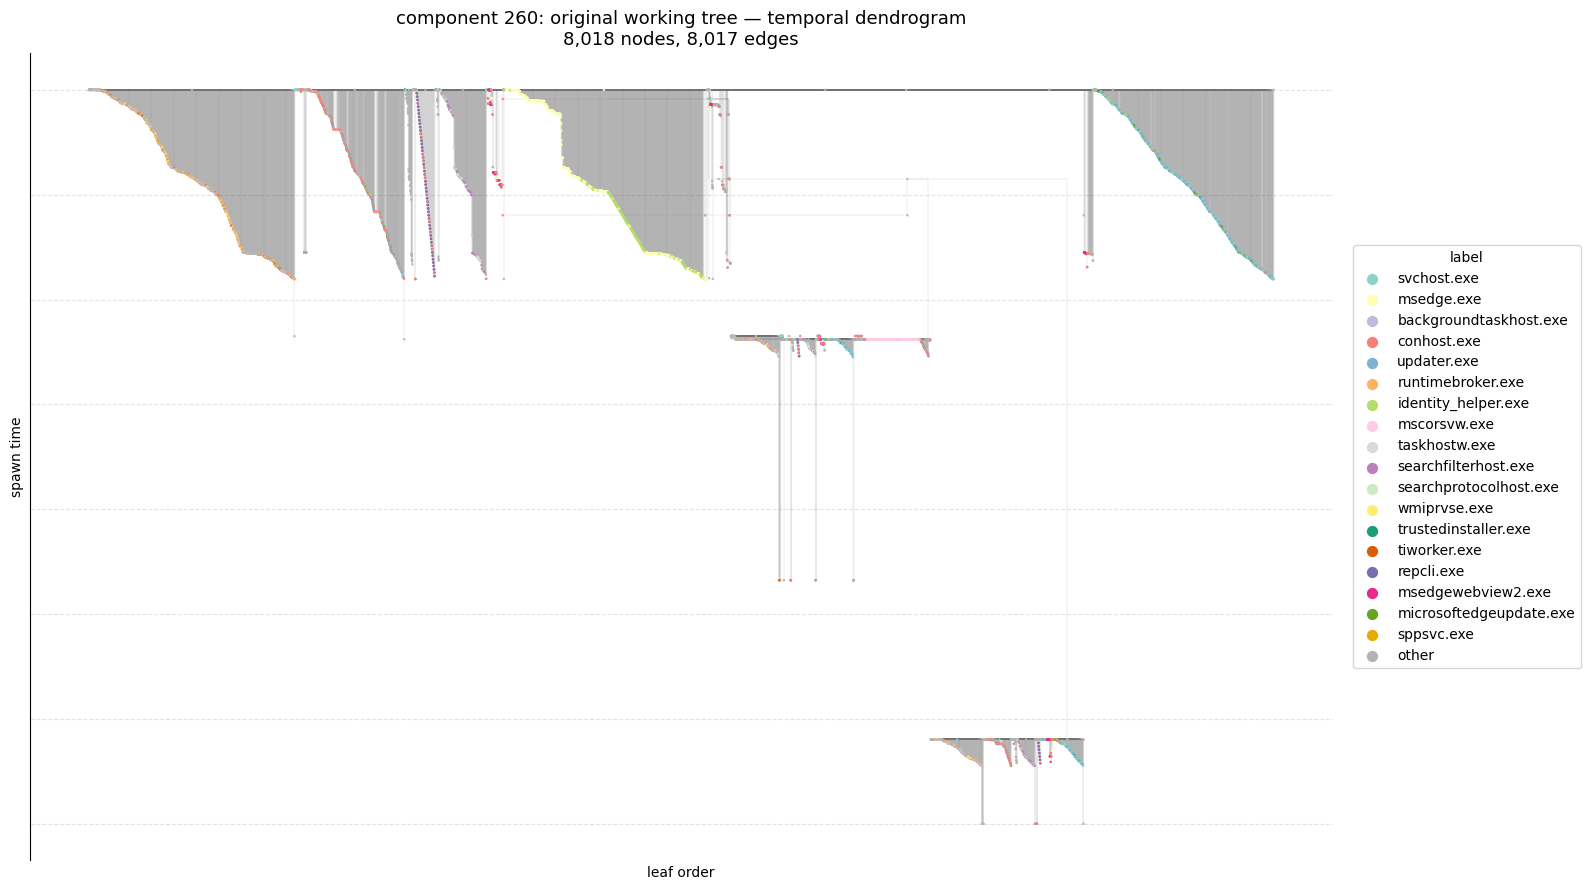

In [7]:
MIN_NODES = 10
MAX_NODES = 100_000
LABEL_QUERY = ""       # examples: powershell, cmd, python, chrome
REQUIRE_TREE = False
SORT_BY = "n_nodes"    # n_nodes, burst_score, max_out_degree, interesting_label_hits

candidate_df = component_df[
    (component_df["n_nodes"] >= MIN_NODES)
    & (component_df["n_nodes"] <= MAX_NODES)
].copy()
if REQUIRE_TREE:
    candidate_df = candidate_df[candidate_df["is_tree"]]
if LABEL_QUERY:
    candidate_df = candidate_df[
        candidate_df["top_labels"].str.lower().str.contains(LABEL_QUERY.lower(), regex=False)
    ]
candidate_df = candidate_df.sort_values(SORT_BY, ascending=False).reset_index(drop=True)
if candidate_df.empty:
    raise RuntimeError("No candidate components matched the filters.")
display(candidate_df.head(50))

COMPONENT_ID = int(candidate_df.iloc[0]["component_id"])
USE_SPANNING_TREE_IF_NEEDED = True
SUBTREE_ROOT = None      # paste a process GUID from focus_df to zoom
FORCE_MAX_NODES = 3000

component_tree, used_spanning_tree, reoriented = make_component_tree(
    COMPONENT_ID, use_spanning_tree=USE_SPANNING_TREE_IF_NEEDED
)
focus_df = subtree_size_table(component_tree)
display(focus_df.head(30))

T = descendants_view(component_tree, SUBTREE_ROOT)
print("COMPONENT_ID:", COMPONENT_ID)
print("used spanning tree:", used_spanning_tree)
print("required fallback reorientation:", reoriented)
print("working tree nodes/edges:", f"{T.number_of_nodes():,}", f"{T.number_of_edges():,}")
print("top labels:", top_label_string(T.nodes(), k=12))
display(component_deltas(T).describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.5, 0.75, 0.9]).to_frame().T)

draw_tree_gallery(T, f"component {COMPONENT_ID}: original working tree", force_max_nodes=FORCE_MAX_NODES)


## 7. Build the fitting corpus


In [8]:
FIT_COMPONENT_LIMIT = 100
FIT_USE_SPANNING_TREE_IF_NEEDED = True

fit_component_ids = candidate_df.head(FIT_COMPONENT_LIMIT)["component_id"].astype(int).tolist()
fit_trees = []
fit_failures = []
for cid in fit_component_ids:
    try:
        fit_tree, _, _ = make_component_tree(
            cid, use_spanning_tree=FIT_USE_SPANNING_TREE_IF_NEEDED
        )
        fit_trees.append(fit_tree)
    except Exception as exc:
        fit_failures.append((cid, repr(exc)))

print("fit trees:", len(fit_trees))
print("fit nodes:", f"{sum(tree.number_of_nodes() for tree in fit_trees):,}")
print("fit failures:", len(fit_failures))
if fit_failures:
    display(pd.DataFrame(fit_failures, columns=["component_id", "error"]).head(20))


fit trees: 100
fit nodes: 106,241
fit failures: 0


## 8. Fit and apply the star coarsener

`d` is the witness threshold, `m` is the number of witnesses needed to learn a `(parent_label, child_label)` pair, and `contract_d` is the smaller transform-time threshold after the pair has been learned.


In [9]:
STAR_D = 4
STAR_M = 2
STAR_CONTRACT_D = 3

star = ParametricStarCoarsener(d=STAR_D, m=STAR_M, contract_d=STAR_CONTRACT_D)
star.fit(fit_trees)
H_star = star.transform(T)

star_summary = pd.DataFrame(
    [
        {
            "stage": "raw",
            "nodes": T.number_of_nodes(),
            "edges": T.number_of_edges(),
            "ratio_to_raw": 1.0,
        },
        {
            "stage": "star",
            "nodes": H_star.number_of_nodes(),
            "edges": H_star.number_of_edges(),
            "ratio_to_raw": H_star.number_of_nodes() / T.number_of_nodes(),
        },
    ]
)
display(star_summary)
print("learned star vocabulary entries:", len(star.encoder_.vocab))
display(token_count_frame(H_star).head(30))


,stage,nodes,edges,ratio_to_raw
0,raw,8018,8017,1.000000
1,star,5208,5207,0.649539


learned star vocabulary entries: 111


,token,occurrences
0,'msedge.exe',865
1,'backgroundtaskhost.exe',708
2,'conhost.exe',412
3,'runtimebroker.exe',371
4,'identity_helper.exe',354
5,'updater.exe',267
6,'taskhostw.exe',219
7,'wmiprvse.exe',177
8,'tiworker.exe',159
9,'microsoftedgeupdate.exe',92


## 9. Visualize the intermediate star-coarsened result

The first pair of plots colors the original process tree by star occurrence. The second pair draws the star quotient tree itself.


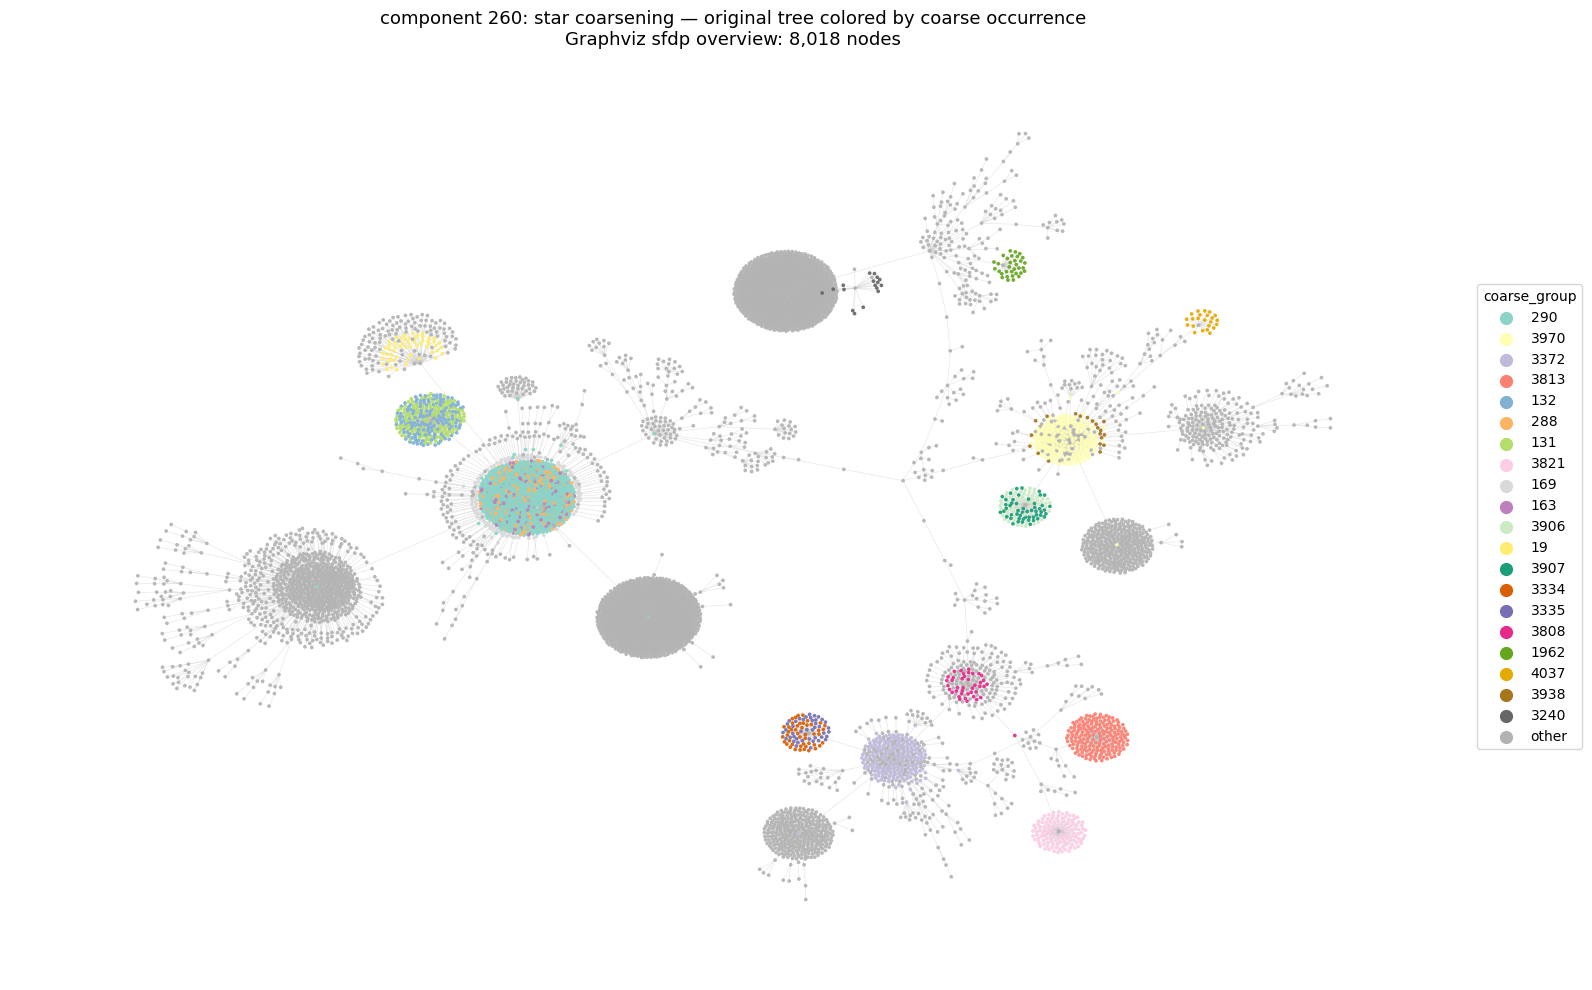

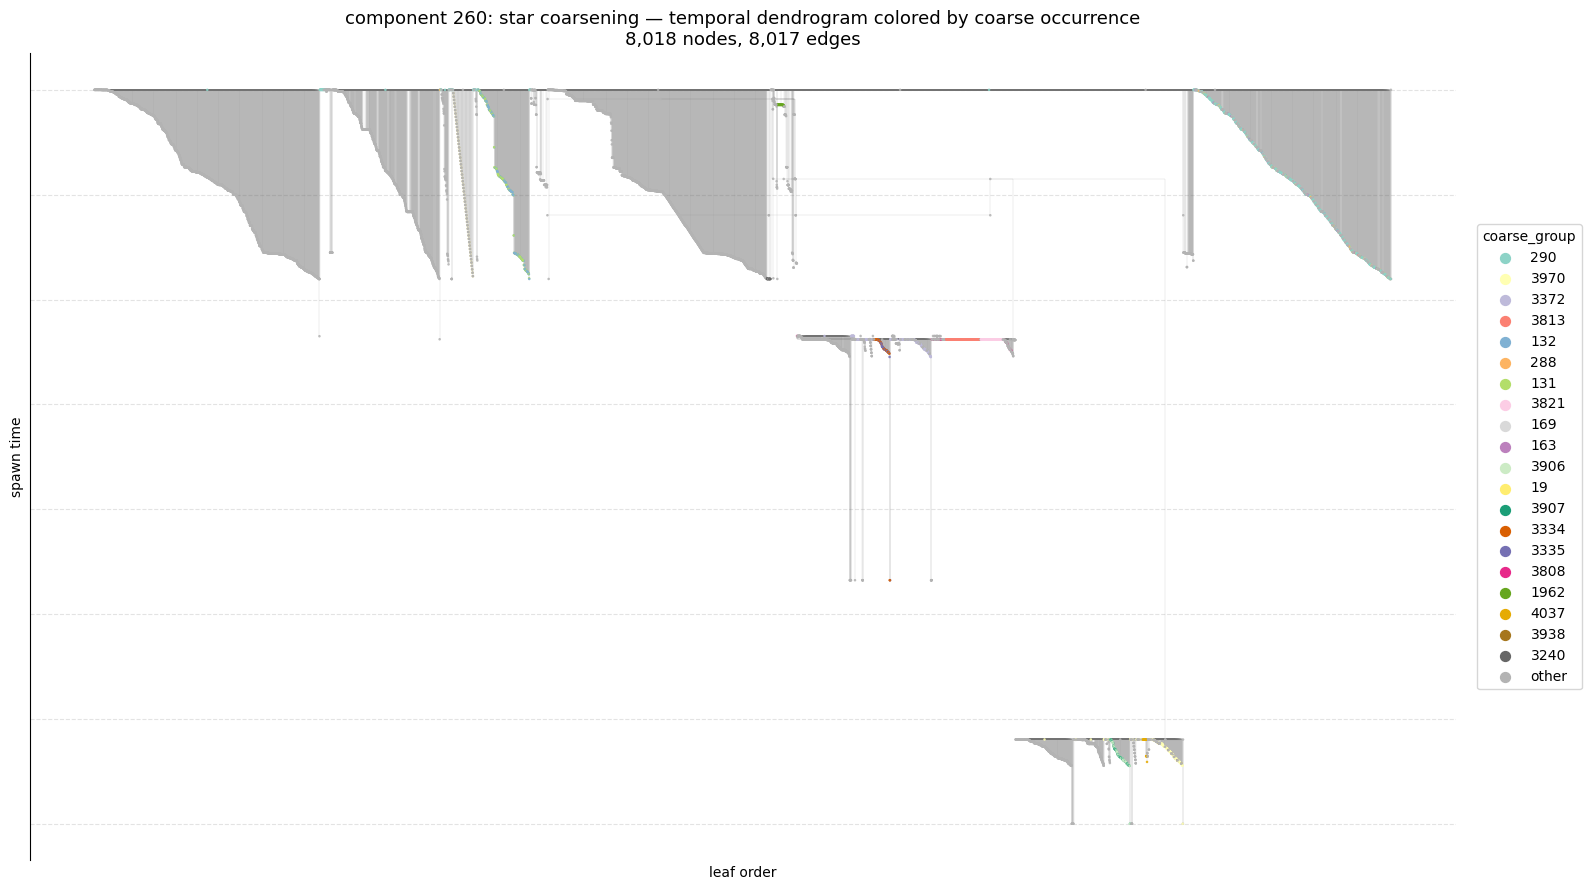

Drawing nodes/edges: 5,208 5,207


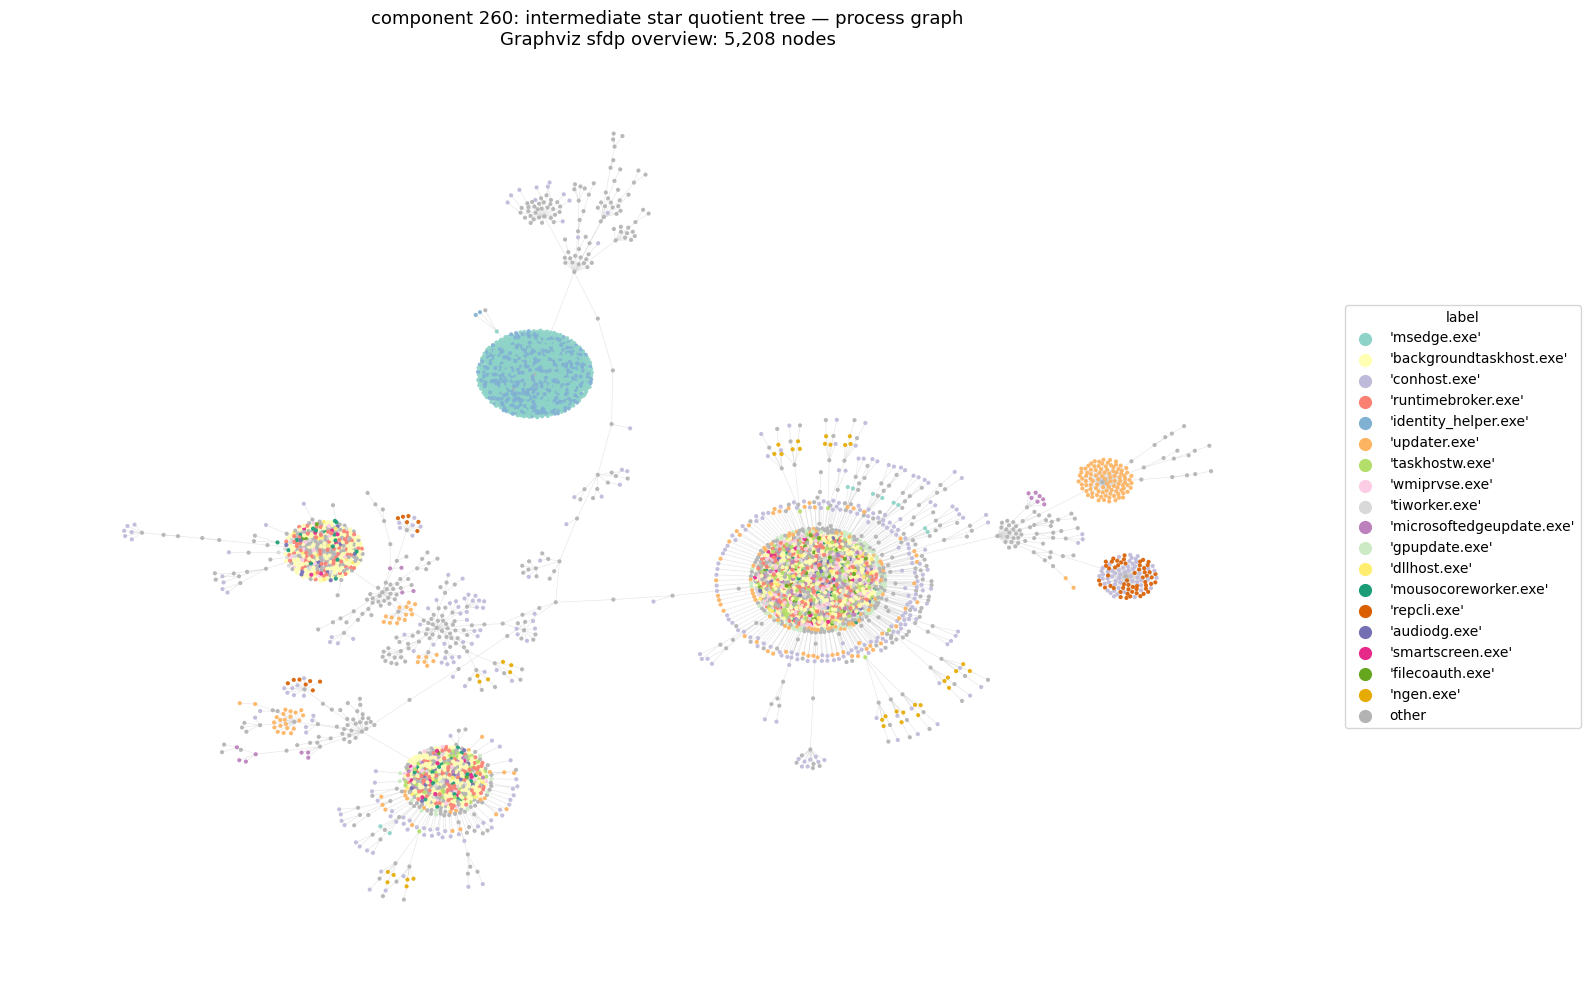

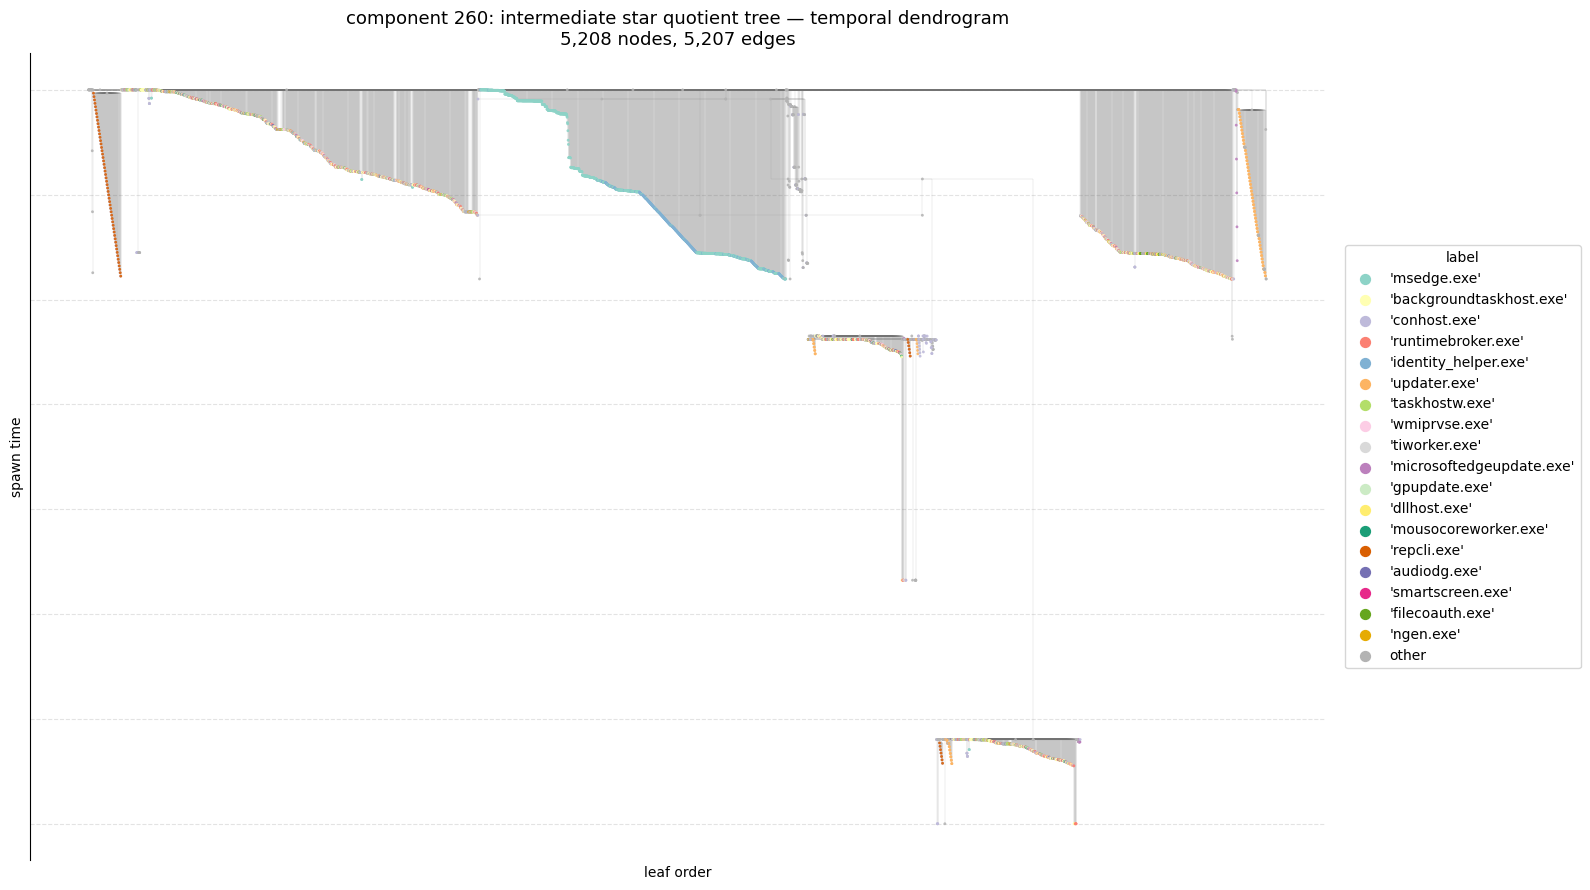

In [10]:
draw_original_by_groups(
    T,
    H_star,
    title=f"component {COMPONENT_ID}: star coarsening",
    max_nodes=20_000,
)

D_star = encoded_display_graph(H_star, T)
draw_tree_gallery(
    D_star,
    f"component {COMPONENT_ID}: intermediate star quotient tree",
    force_max_nodes=20_000,
)


## 10. Fit edge BPE directly on the star-coarsened trees

The transformed Star graphs already satisfy the common `label + size + time` fitting contract. Edge BPE therefore fits and transforms them directly; no quotient adapter or previous-stage vocabulary is passed by the user.


In [11]:
BPE_NUM_MERGES = 64
BPE_MIN_PAIR_COUNT = 2
BPE_BACKEND = "python"   # set to "numba" for warmed optimized BPE if numba is installed

star_fit_graphs = [star.transform(g) for g in fit_trees]

bpe = EdgeBPECoarsener(
    num_merges=BPE_NUM_MERGES,
    min_pair_count=BPE_MIN_PAIR_COUNT,
    backend=BPE_BACKEND,
)
bpe.fit(star_fit_graphs)
H_star_bpe = bpe.transform(H_star)

summary_df = pd.DataFrame(
    [
        {
            "stage": "raw",
            "nodes": T.number_of_nodes(),
            "edges": T.number_of_edges(),
            "ratio_to_raw": 1.0,
        },
        {
            "stage": "star",
            "nodes": H_star.number_of_nodes(),
            "edges": H_star.number_of_edges(),
            "ratio_to_raw": H_star.number_of_nodes() / T.number_of_nodes(),
        },
        {
            "stage": "star_then_bpe",
            "nodes": H_star_bpe.number_of_nodes(),
            "edges": H_star_bpe.number_of_edges(),
            "ratio_to_raw": H_star_bpe.number_of_nodes() / T.number_of_nodes(),
        },
    ]
)
display(summary_df)
print("learned BPE merges:", len(bpe.history_))
display(pd.DataFrame(bpe.history_).head(40))


,stage,nodes,edges,ratio_to_raw
0,raw,8018,8017,1.000000
1,star,5208,5207,0.649539
2,star_then_bpe,5092,5091,0.635071


learned BPE merges: 64


,rank,token,parent_label,child_label,parent_token,child_token,count,count_semantics,parent_count,child_count,parent_size,child_size,score,pair_score,actual_events
0,0,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...","(star, services.exe, svchost.exe)",backgroundtaskhost.exe,"(star, services.exe, svchost.exe)",backgroundtaskhost.exe,5169,raw_matching_edges,65,5169,2,1,5169.0,count,65
1,1,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",git.exe,git.exe,git.exe,git.exe,5119,raw_matching_edges,11530,11530,1,1,5119.0,count,3169
2,2,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...","(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,5104,raw_matching_edges,65,5104,3,1,5104.0,count,65
3,3,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...","(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,5039,raw_matching_edges,65,5039,4,1,5039.0,count,65
4,4,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...","(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,4974,raw_matching_edges,65,4974,5,1,4974.0,count,65
5,5,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...","(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,4909,raw_matching_edges,65,4909,6,1,4909.0,count,65
6,6,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...","(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,4844,raw_matching_edges,65,4844,7,1,4844.0,count,65
7,7,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...","(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,4779,raw_matching_edges,65,4779,8,1,4779.0,count,64
8,8,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...","(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,4715,raw_matching_edges,64,4715,9,1,4715.0,count,64
9,9,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...","(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,4651,raw_matching_edges,64,4651,10,1,4651.0,count,64


## 11. Visualize the final star → BPE result


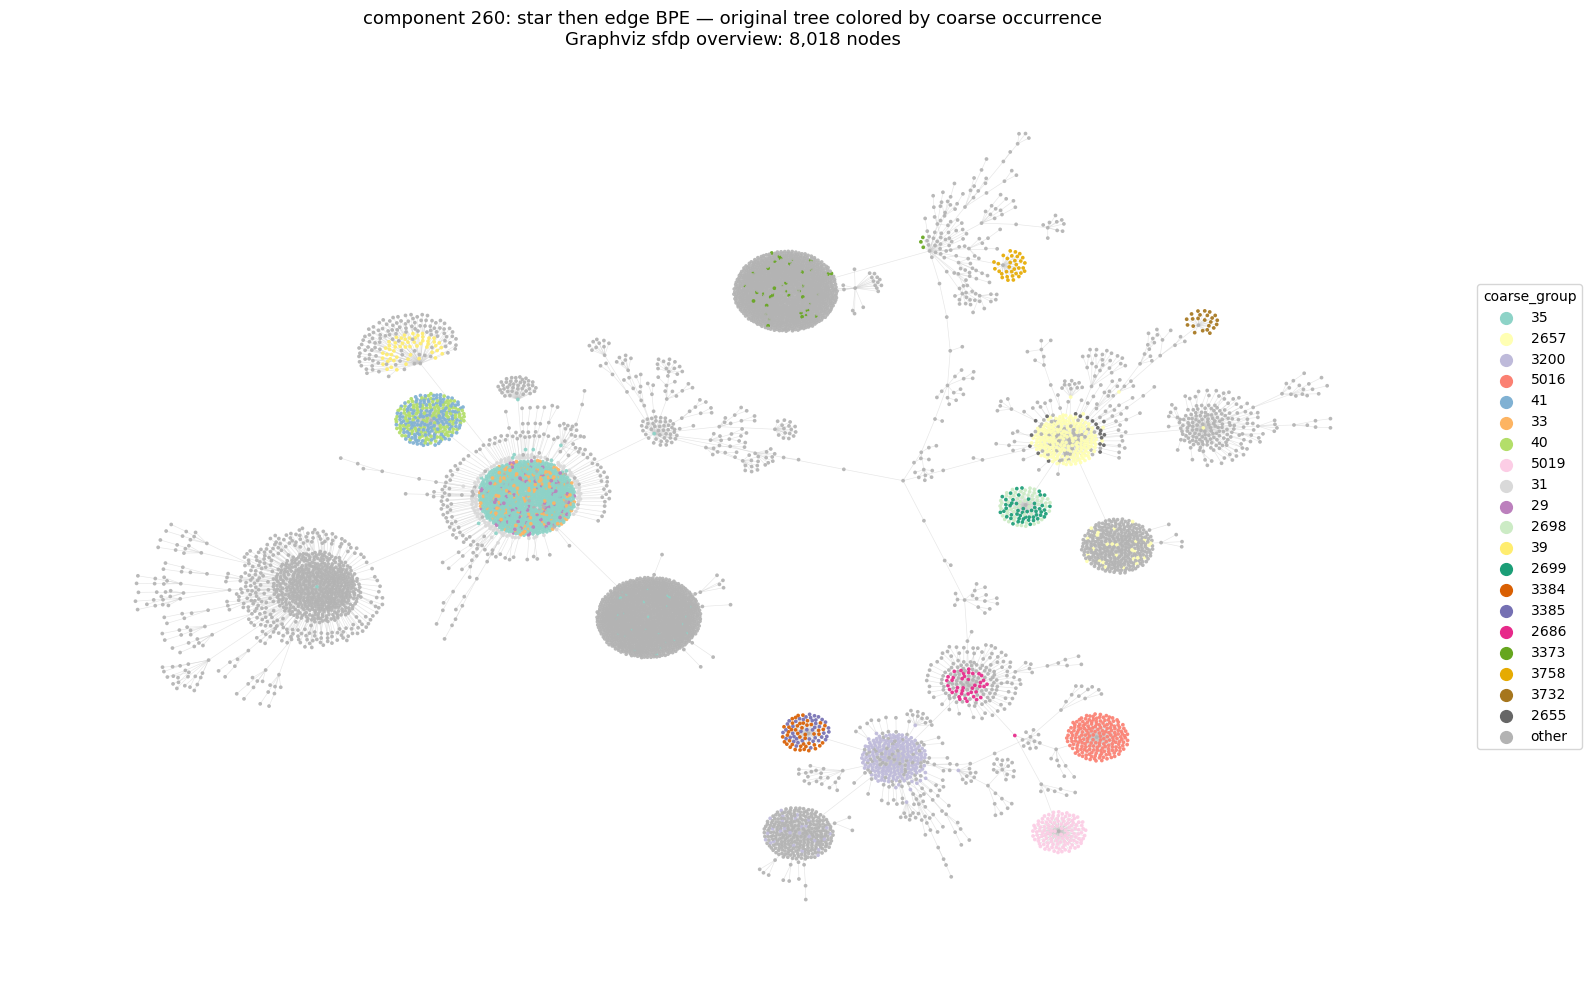

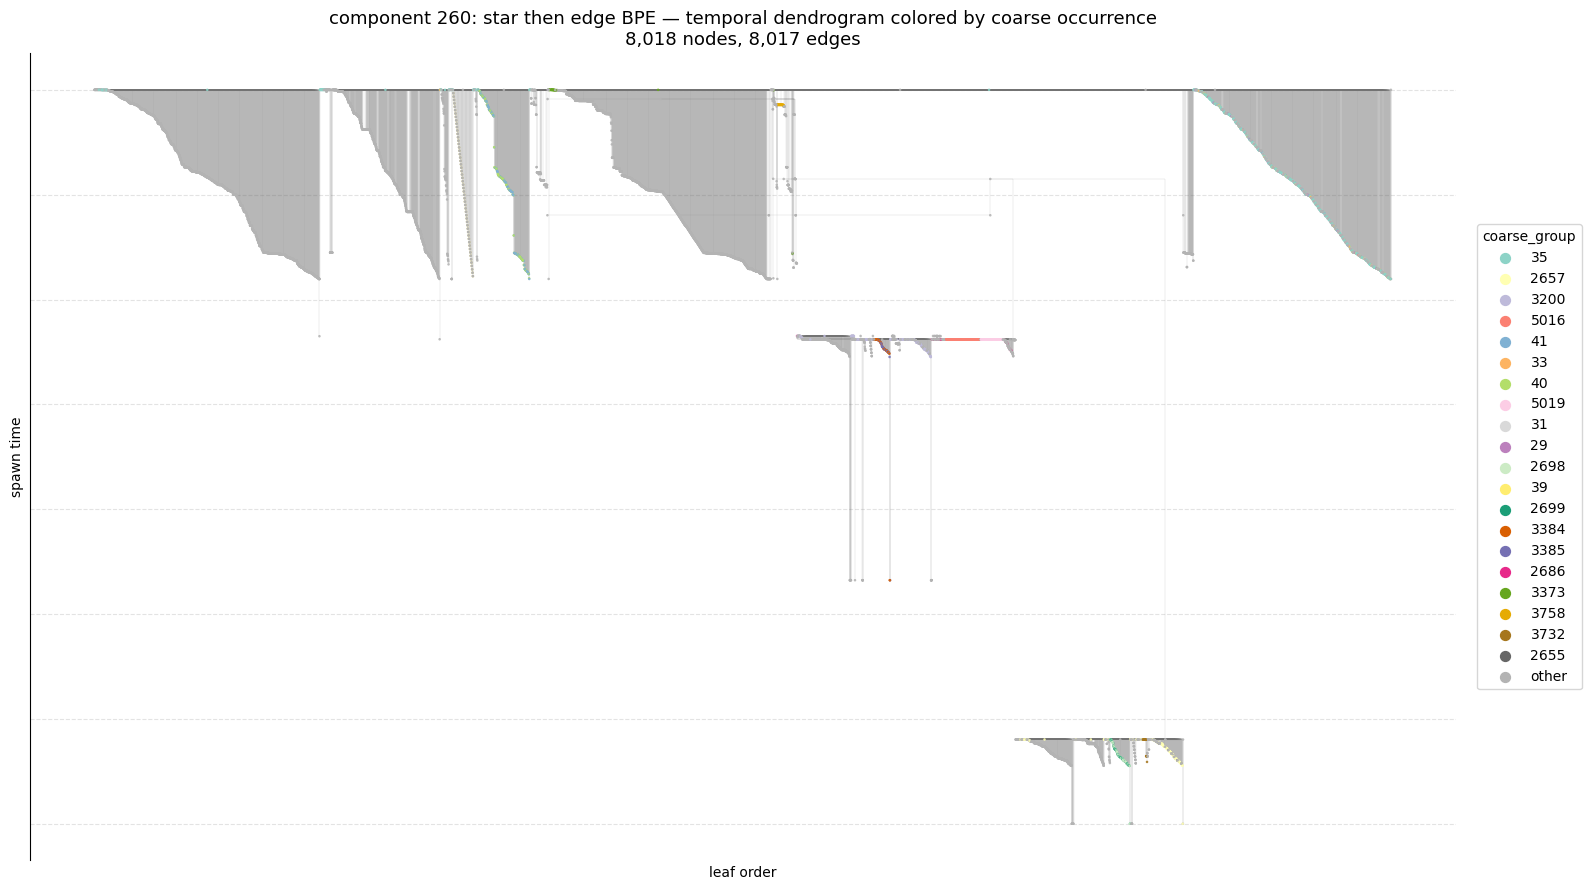

Drawing nodes/edges: 5,092 5,091


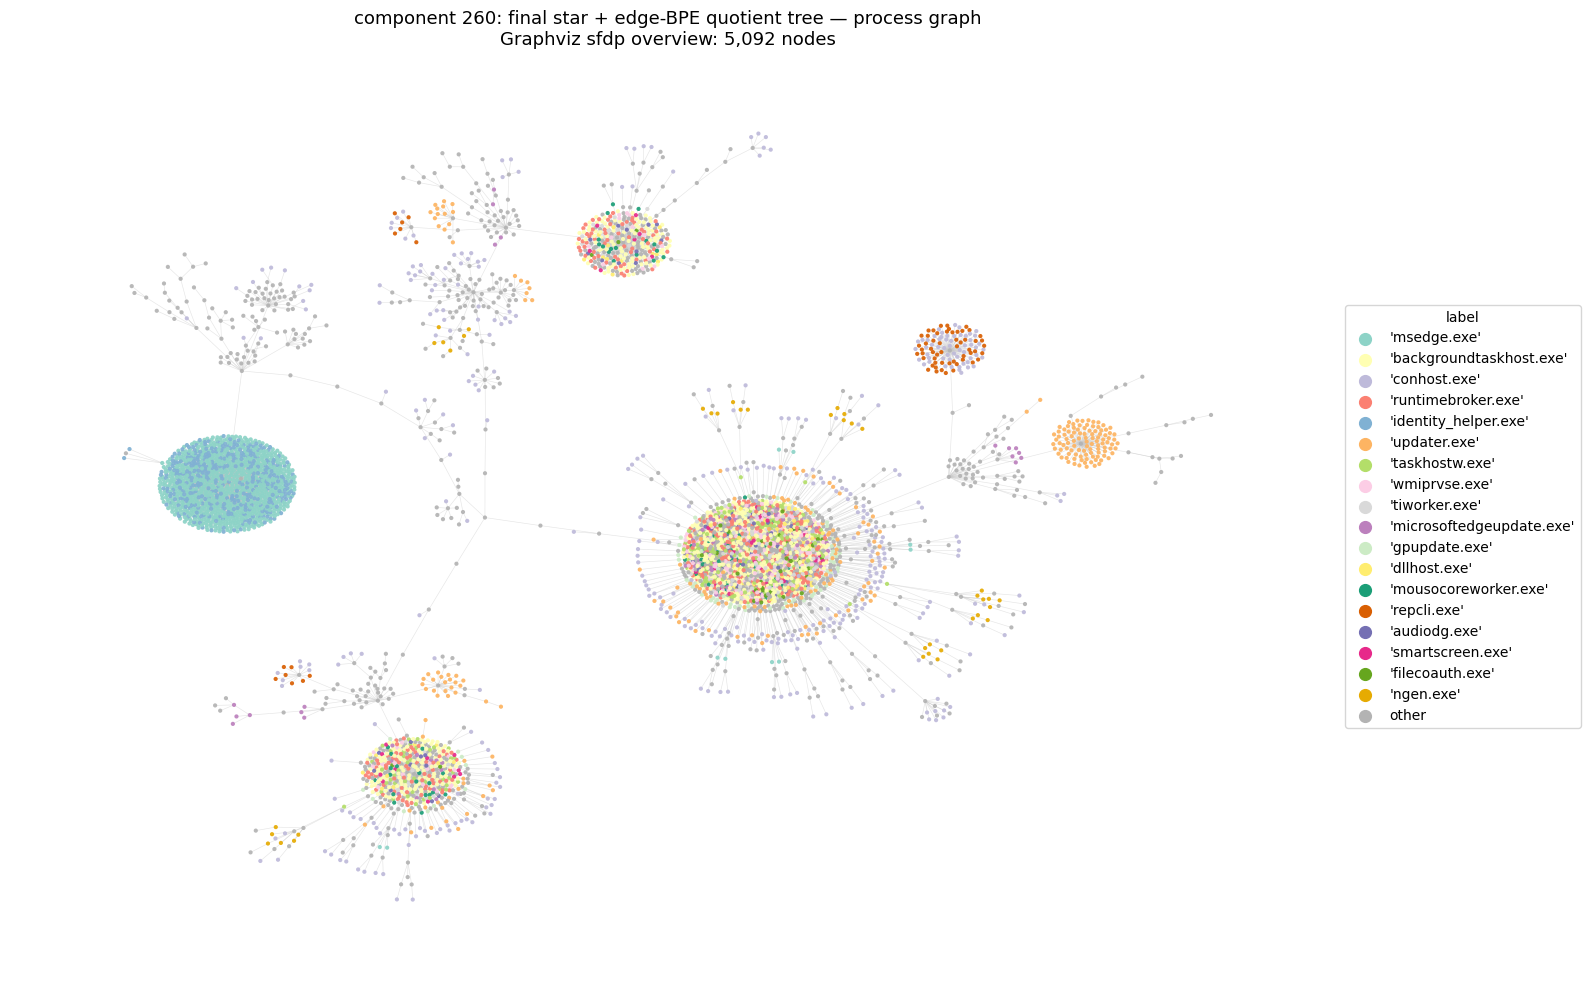

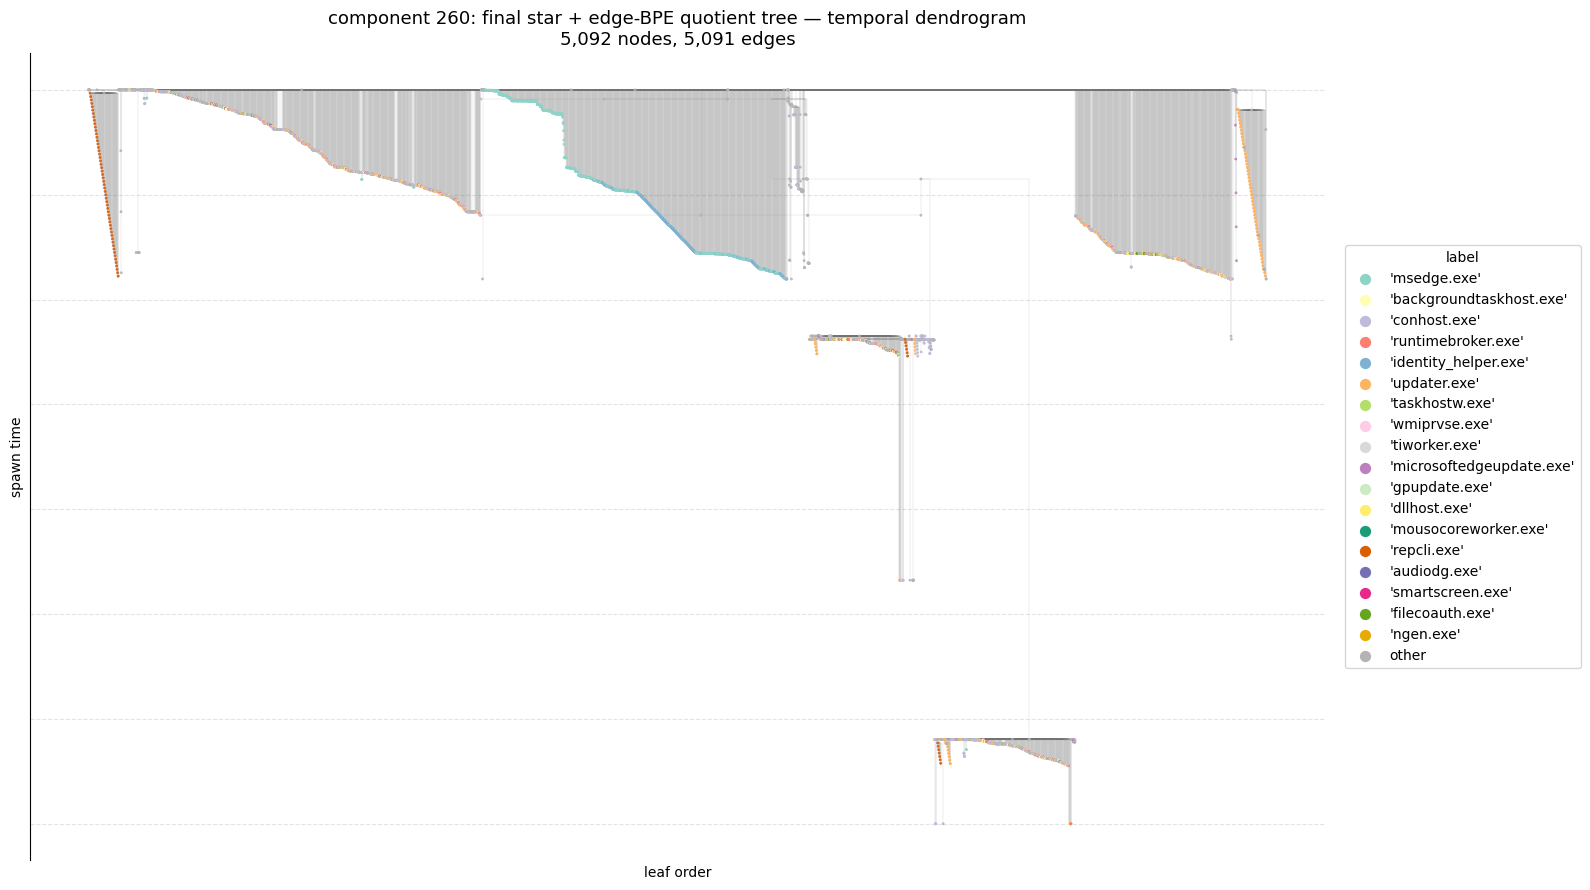

In [12]:
draw_original_by_groups(
    T,
    H_star_bpe,
    title=f"component {COMPONENT_ID}: star then edge BPE",
    max_nodes=20_000,
)

D_final = encoded_display_graph(H_star_bpe, T)
draw_tree_gallery(
    D_final,
    f"component {COMPONENT_ID}: final star + edge-BPE quotient tree",
    force_max_nodes=20_000,
)


## 12. Compact diagnostics


In [13]:
print("Star-token occurrences in selected tree:")
display(token_count_frame(H_star).head(30))

print("Final token occurrences:")
display(token_count_frame(H_star_bpe).head(40))

if bpe.history_:
    history_df = pd.DataFrame(bpe.history_)
    columns = [
        column
        for column in [
            "rank",
            "token",
            "parent_label",
            "child_label",
            "count",
            "actual_events",
        ]
        if column in history_df.columns
    ]
    display(history_df[columns].head(50))
else:
    print("No BPE pair reached BPE_MIN_PAIR_COUNT on the star-stage fitting corpus.")

# Stage-local inverse transforms run in reverse order.
H_star_recovered = bpe.inverse_transform(H_star_bpe)
T_recovered = star.inverse_transform(H_star_recovered)


def uid_edges(graph):
    return {
        (graph.nodes[u].get("uid", u), graph.nodes[v].get("uid", v))
        for u, v in graph.edges
    }


assert uid_edges(T_recovered) == uid_edges(T)
assert {
    data["uid"]: (data["label"], data["time"])
    for _, data in T_recovered.nodes(data=True)
} == {
    data["uid"]: (data["label"], data["time"])
    for _, data in T.nodes(data=True)
}
print("Star → BPE → BPE decode → Star decode roundtrip passed.")


Star-token occurrences in selected tree:


,token,occurrences
0,'msedge.exe',865
1,'backgroundtaskhost.exe',708
2,'conhost.exe',412
3,'runtimebroker.exe',371
4,'identity_helper.exe',354
5,'updater.exe',267
6,'taskhostw.exe',219
7,'wmiprvse.exe',177
8,'tiworker.exe',159
9,'microsoftedgeupdate.exe',92


Final token occurrences:


,token,occurrences
0,'msedge.exe',828
1,'backgroundtaskhost.exe',630
2,'conhost.exe',412
3,'runtimebroker.exe',371
4,'identity_helper.exe',354
5,'updater.exe',267
6,'taskhostw.exe',219
7,'wmiprvse.exe',177
8,'tiworker.exe',159
9,'microsoftedgeupdate.exe',92


,rank,token,parent_label,child_label,count,actual_events
0,0,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...","(star, services.exe, svchost.exe)",backgroundtaskhost.exe,5169,65
1,1,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",git.exe,git.exe,5119,3169
2,2,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...","(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,5104,65
3,3,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...","(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,5039,65
4,4,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...","(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,4974,65
5,5,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...","(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,4909,65
6,6,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...","(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,4844,65
7,7,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...","(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,4779,64
8,8,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...","(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,4715,64
9,9,"(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...","(edge_bpe, EdgeBPECoarsener:c163ce9b77084ec9b3...",backgroundtaskhost.exe,4651,64


Star → BPE → BPE decode → Star decode roundtrip passed.


## 13. Notes

- Lower `STAR_M` or `STAR_D` if the fitting corpus learns no star rules.
- Lower `BPE_MIN_PAIR_COUNT` if no BPE pair is learned.
- Reduce `FIT_COMPONENT_LIMIT` for a quick exploratory run.
- The BPE stage now consumes Star output directly through the common fitting schema.
- `backend="numba"` is accepted but temporarily falls back to the attachment-independent Python fitter in this pass.
